# Generate the next iteration of a sweep

Given one or more sweeps, this notebook compares their finished trials and suggests refined
parameter ranges for the next sweep, using the results in the [Que](../../que/README.md) (each
trial's `wandb.sweep_id`, nested run config, and `results.best_val_loss`). The target metric is
`Best/Val_loss`, the same metric the sweeps minimise.

Seed noise comes from the [seed comparison](../seed_comparison/results.ipynb): 10 seeds of the
config from [S3D sweep 4](../../configfiles/sweeps/S3D/exp004/README.md)'s best run.

**Caveats**
- Only finished trials are in the Que's `old_runs`. Trials that wandb's hyperband stopped early
  also land there (they're marked failed in wandb, but the Que treats them as complete), so
  they're included, scored by their best val loss before the cut.
- The epochs each trial trained for are not stored in the Que's results, so this notebook can't
  show where hyperband cut runs short. Use wandb's `Epoch` summary for that.
- Sweep 4 ran across the move to the `_cutoff_9` split. Only its `asl100_cutoff_9` trials are
  loaded, and they came late in that sweep, after the optimiser had already learnt from the
  old-split trials, so its best-so-far curve isn't comparable to a fresh sweep's.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.results import get_asset_path, get_out_stub, get_stash_path, load_runs
from src.results.sweeping.helpers import (
    SweepRef,
    load_sweep_key_map,
    load_tuned_params,
    suggest_ranges,
    sweep_frame,
)
from src.run_types import CONFIGS_PATH
from src.visualise2 import (
    LINE_PALETTE,
    plot_loss_curves,
    plot_metric_correlation,
    save_fig,
    set_thesis_style,
)

set_thesis_style()

## Sweeps to analyse

Edit `sweeps` to analyse other sweeps. Diverged trials (best val loss at or above the loss of a
uniform prediction over the split's classes) are kept in the tables but left out of the scatter
plots.

In [2]:
project_name = "sweeping"
model = "S3D"
split = "asl100_cutoff_9"
n_classes = 100
chance_loss = float(np.log(n_classes))

sweep_root = CONFIGS_PATH / "sweeps" / model
sweeps = [
    SweepRef("exp004", "qsh82m4w", sweep_root / "exp004"),
    SweepRef("exp005", "n4brjkmn", sweep_root / "exp005"),
    SweepRef("exp006", "9efnzegw", sweep_root / "exp006"),
]


def stash_path(source: str):
    return get_stash_path(get_out_stub(split, model, source), base_name="runs")


def asset_path(metric_descriptor: str):
    stub = get_out_stub(split, model, "-".join(s.label for s in sweeps))
    return get_asset_path(metric_descriptor, stub, project_name)

### Stash the runs from the Que

Run once on the training server, then comment out.

In [3]:
# from src.results import fetch_runs, find_runs
# from src.run_types import RESULTS_DIR
#
# stash_dir = get_stash_path("").parent
# stash_dir.mkdir(exist_ok=True)
# for s in sweeps:
#     find_runs(
#         {
#             "wandb": {"sweep_id": lambda x, sid=s.sweep_id: x == sid},
#             "admin": {"split": lambda x: x == split},
#         },
#         output_path=str(stash_path(s.sweep_id)),
#     )
# fetch_runs(RESULTS_DIR / "seed_comparison" / "filters.py", output_path=str(stash_path("seed_comparison")))

In [4]:
runs = {s.label: load_runs(stash_path(s.sweep_id)) for s in sweeps}
seed_runs = load_runs(stash_path("seed_comparison"))

tuned = {s.label: load_tuned_params(s.sweep_dir / "config.yaml") for s in sweeps}
frames = {
    s.label: sweep_frame(
        runs[s.label], load_sweep_key_map(s.sweep_dir / "base.py"), list(tuned[s.label])
    )
    for s in sweeps
}

seed_loss = pd.Series([r.results.best_val_loss for r in seed_runs])
seed_mean, seed_std = seed_loss.mean(), seed_loss.std()
print(f"Seed noise ({len(seed_loss)} seeds): best val loss {seed_mean:.3f} ± {seed_std:.3f} (std)")

Seed noise (10 seeds): best val loss 0.880 ± 0.039 (std)


## Sweep comparison

`top5_mean` is less optimistic than `best_val_loss`: the minimum over many trials is biased low,
since a trial can win partly by getting a lucky seed. Treat gaps smaller than about 2 seed stds
as noise.

In [5]:
summary = pd.DataFrame(
    {
        label: {
            "trials": len(df),
            "diverged": int((df.best_val_loss >= chance_loss).sum()),
            "best_val_loss": df.best_val_loss.min(),
            "top5_mean": df.best_val_loss.nsmallest(5).mean(),
            "best_val_acc": df.best_val_acc.max(),
            "best_run": df.loc[df.best_val_loss.idxmin(), "run_id"],
        }
        for label, df in frames.items()
    }
).T
summary

,trials,diverged,best_val_loss,top5_mean,best_val_acc,best_run
exp004,23,1,0.905821,0.976402,77.810651,jrinmilf
exp005,135,53,1.185969,1.25006,74.556213,czopef0v
exp006,50,1,1.263694,1.327448,70.414201,8blz4rux


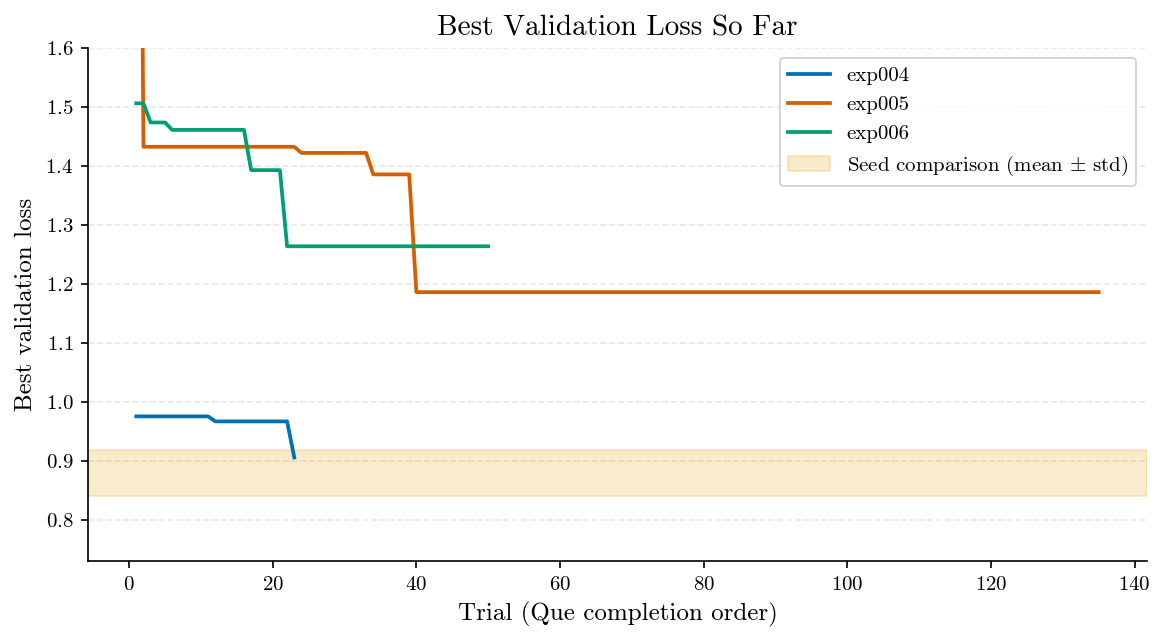

In [6]:
n_max = max(len(df) for df in frames.values())
best_so_far = {
    label: df.best_val_loss.cummin().reindex(range(n_max)).to_numpy() for label, df in frames.items()
}
fig, ax = plot_loss_curves(
    np.arange(1, n_max + 1),
    best_so_far,
    title="Best Validation Loss So Far",
    xlabel="Trial (Que completion order)",
    ylabel="Best validation loss",
)
ax.axhspan(
    seed_mean - seed_std,
    seed_mean + seed_std,
    color=LINE_PALETTE[len(best_so_far)],
    alpha=0.2,
    label=r"Seed comparison (mean $\pm$ std)",
)
ax.set_ylim(top=1.6)
ax.legend(loc="upper right")
save_fig(fig, asset_path("best_so_far"))
plt.show()

## Parameter effects

Kendall's tau between each swept parameter and best val loss, over all trials in each sweep.
Negative values mean larger parameter values give lower (better) loss. Tau is rank-based, so
log-uniform parameters need no transform.

In [7]:
kendall = pd.DataFrame(
    {
        label: df[list(tuned[label])].corrwith(df.best_val_loss, method="kendall")
        for label, df in frames.items()
    }
)
kendall.round(2)

,exp004,exp005,exp006
backbone_init_lr,-0.11,0.22,0.16
backbone_weight_decay,-0.20,-0.02,0.12
classifier_init_lr,0.08,0.13,-0.27
classifier_weight_decay,0.08,-0.03,-0.01
drop_p,0.04,0.01,-0.02
eps,0.25,-0.08,0.42
hflip_p,-0.20,0.10,0.01
magnitude,0.11,NaN,NaN
max_wobble,0.07,NaN,NaN
num_ops,0.01,NaN,NaN


Sweeps 5 and 6 share a base config and search space (sweep 6's ranges are a subset of
sweep 5's), so their trials are pooled below.

In [8]:
search = pd.concat(
    [frames[label].assign(sweep=label) for label in ("exp005", "exp006")], ignore_index=True
)
converged = search[search.best_val_loss < chance_loss]
search_params = tuned["exp005"]

search.nsmallest(10, "best_val_loss").round(6)

,run_id,split,best_val_loss,best_val_acc,test_loss,test_top1,eps,backbone_init_lr,classifier_init_lr,backbone_weight_decay,classifier_weight_decay,drop_p,hflip_p,sweep
39,czopef0v,asl100_cutoff_9,1.185969,74.556213,1.460382,64.341085,0.079350,0.001374,0.000003,0.000023,0.011335,0.452193,0.243583,exp005
126,kxiiw4go,asl100_cutoff_9,1.232354,71.301775,1.385813,67.054264,0.007081,0.000086,0.000015,0.001066,0.000001,0.266178,0.163418,exp005
62,y0fic79f,asl100_cutoff_9,1.237885,72.485207,1.414831,67.829457,0.041282,0.000637,0.000001,0.000001,0.022463,0.399244,0.488709,exp005
156,8blz4rux,asl100_cutoff_9,1.263694,68.934911,1.527730,62.403101,0.000007,0.000053,0.000053,0.000001,0.000002,0.529951,0.191401,exp006
68,s6p1fe36,asl100_cutoff_9,1.283010,73.076923,1.313379,71.317829,0.047194,0.005280,0.000065,0.000047,0.001206,0.078167,0.165712,exp005
183,4l5i0ybk,asl100_cutoff_9,1.310237,65.680473,1.650515,56.201550,0.000021,0.000089,0.000068,0.000003,0.000752,0.592264,0.133090,exp006
57,6ijd16ti,asl100_cutoff_9,1.311082,70.414201,1.668433,61.240310,0.000180,0.000152,0.000008,0.000033,0.000009,0.294631,0.084943,exp005
179,fi982lid,asl100_cutoff_9,1.330208,69.822485,1.584738,60.465116,0.000100,0.000033,0.000063,0.000001,0.000006,0.408719,0.187306,exp006
162,u1xr2ar6,asl100_cutoff_9,1.344344,67.751479,1.560844,58.914729,0.000017,0.000040,0.000058,0.000006,0.000970,0.365290,0.194788,exp006
60,srfv1rcm,asl100_cutoff_9,1.355167,71.301775,1.562457,67.054264,0.008175,0.000284,0.000001,0.035210,0.000087,0.081629,0.261182,exp005


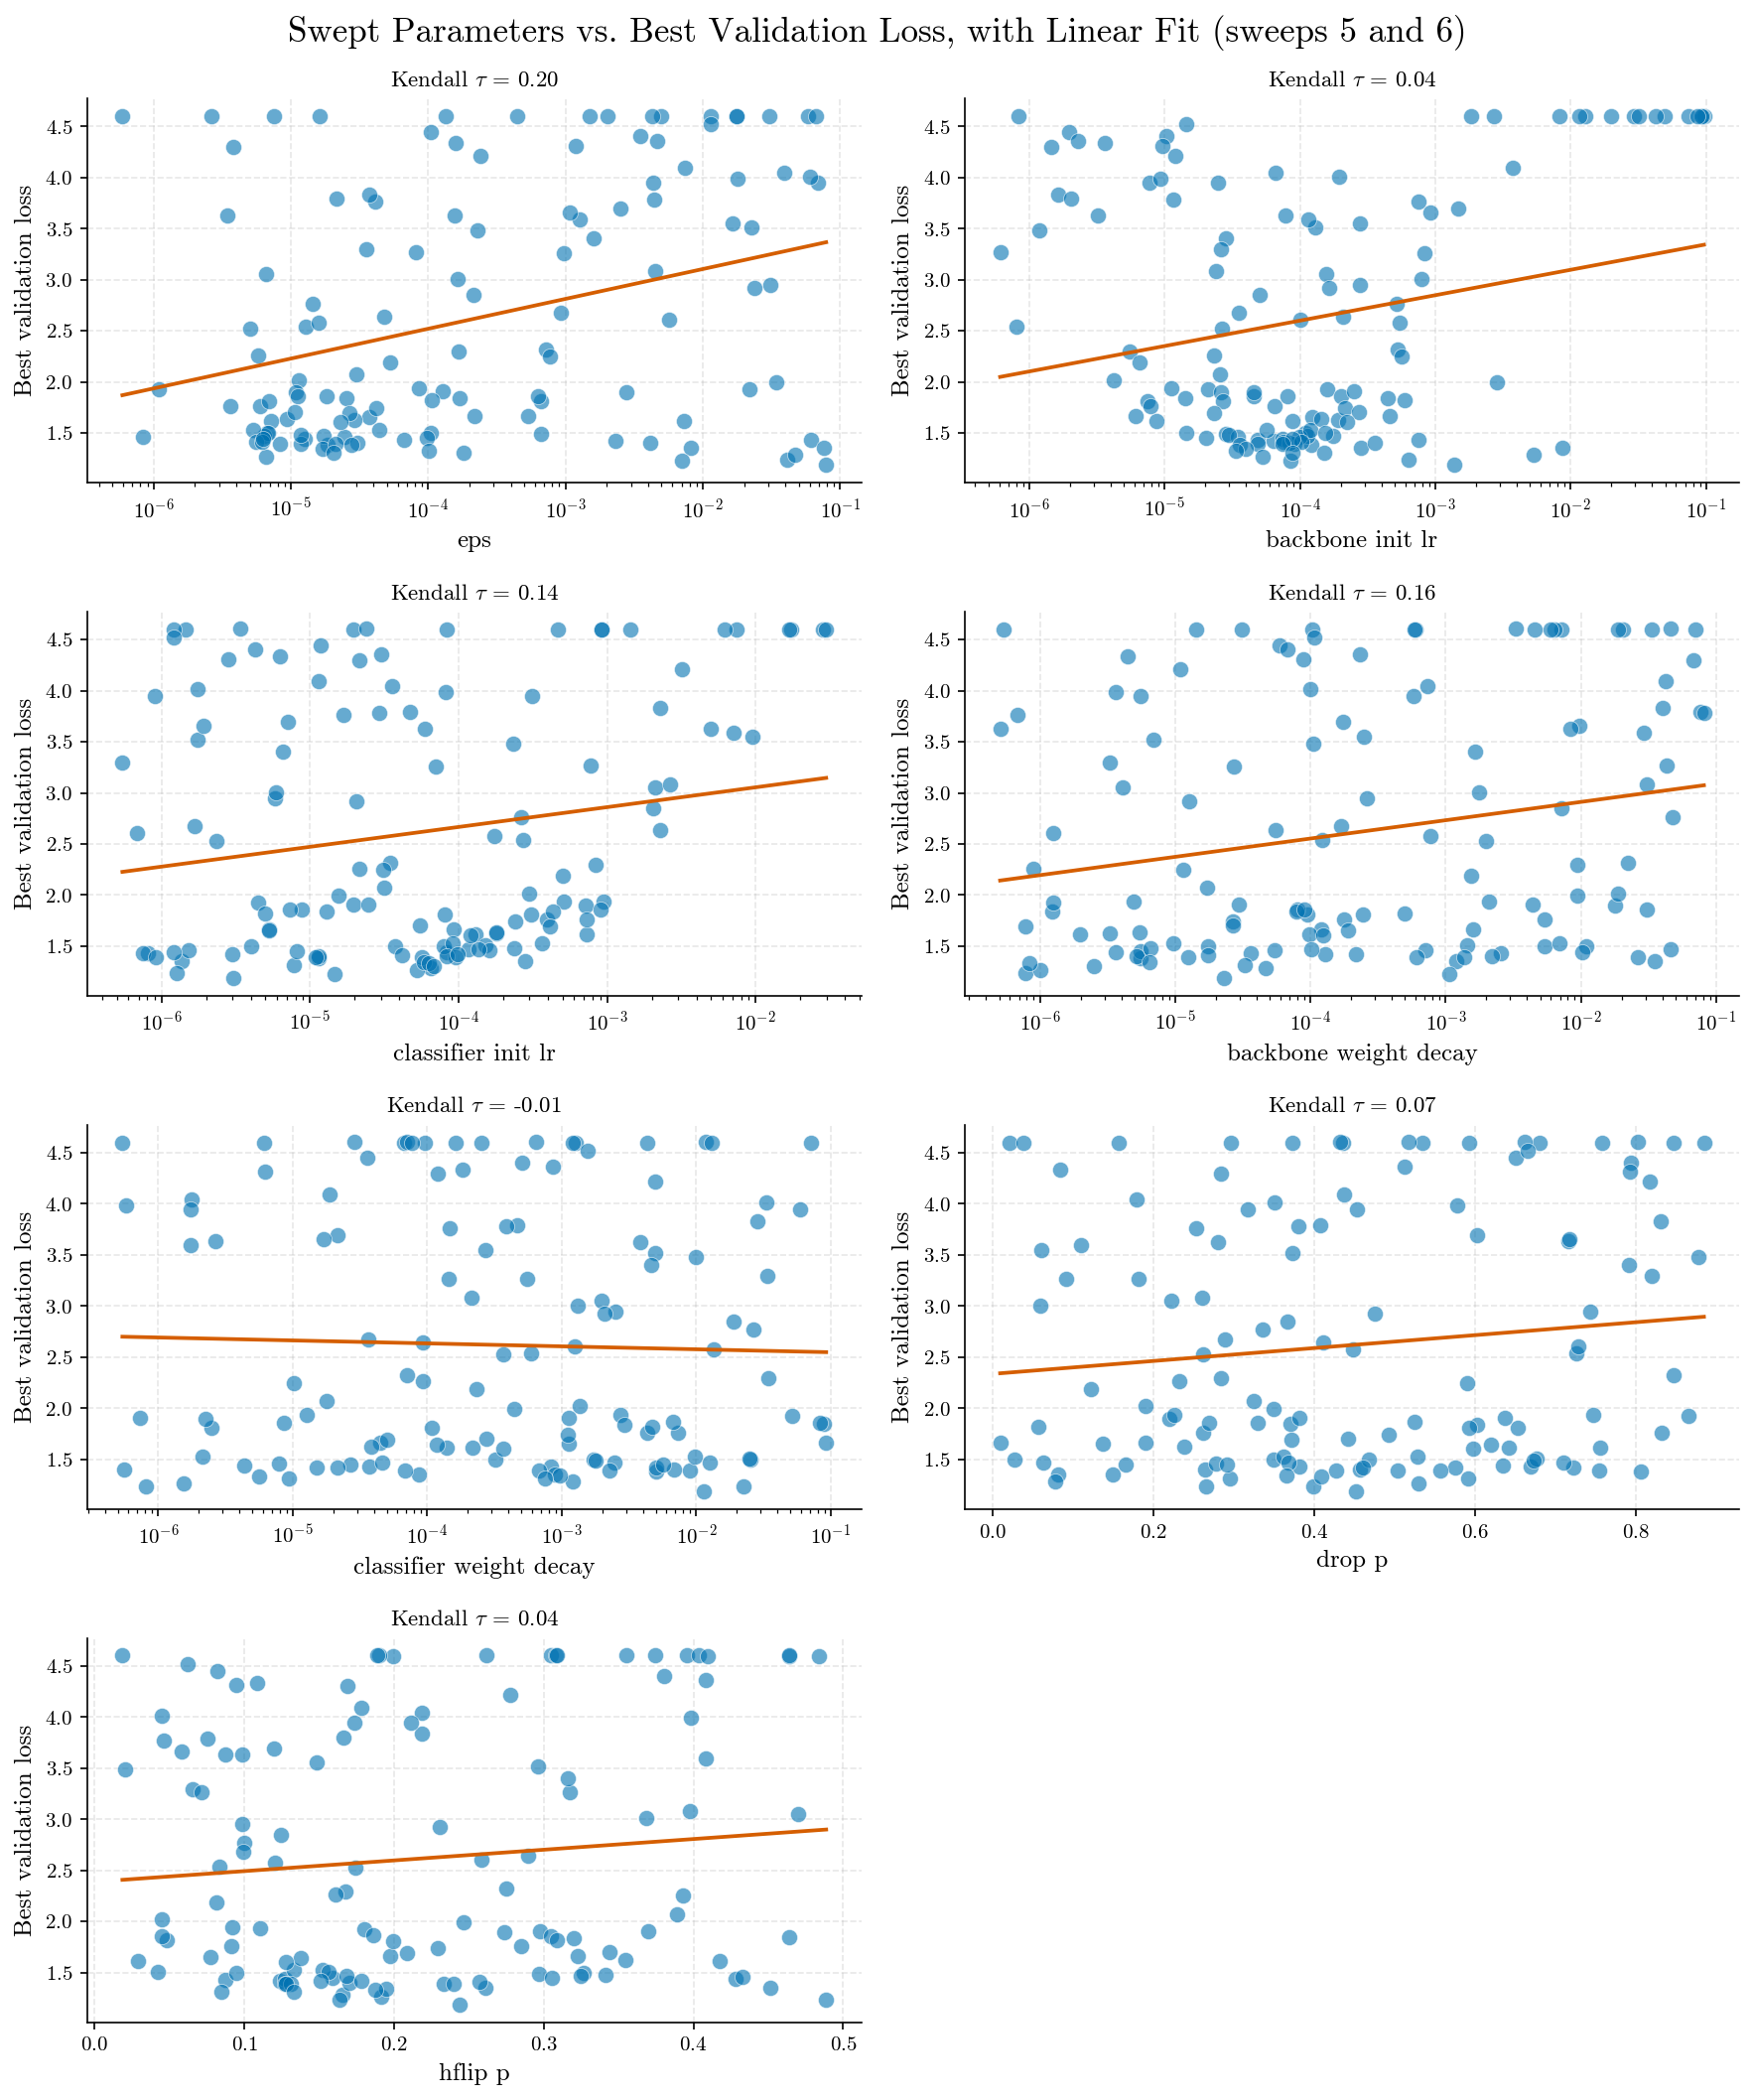

In [9]:
n_cols = 2
n_rows = -(-len(search_params) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.6 * n_rows))
for ax, p in zip(axes.flat, search_params.values()):
    _, _, tau, _ = plot_metric_correlation(
        converged[p.name],
        converged.best_val_loss,
        xlabel=p.name.replace("_", " "),
        ylabel="Best validation loss",
        shade_by_density=False,
        log_x=p.is_log,
        ax=ax,
    )
    # The best (lowest-loss) trials sit along the bottom, where the fit legend would cover
    # them, so report tau in the subplot title instead.
    ax.get_legend().remove()
    ax.set_title(rf"Kendall $\tau$ = {tau:.2f}", fontsize=11)
for ax in axes.flat[len(search_params):]:
    ax.set_visible(False)
fig.suptitle("Swept Parameters vs. Best Validation Loss, with Linear Fit (sweeps 5 and 6)")
fig.tight_layout()
save_fig(fig, asset_path("param_correlation"))
plt.show()

### Optimizer regimes

With AdamW, a large `eps` dominates the second-moment term, so the update is roughly
`lr * m / eps`: the optimizer behaves more like SGD with momentum and needs a larger learning
rate to compensate. Grouping by `eps` shows whether the best trials come from this large-`eps`
regime or from the usual small-`eps` one.

In [10]:
regime = pd.cut(
    converged.eps,
    bins=[0, 1e-4, 1e-2, np.inf],
    labels=["eps <= 1e-4", "1e-4 < eps <= 1e-2", "eps > 1e-2"],
)
converged.groupby([regime, "sweep"], observed=True).agg(
    trials=("best_val_loss", "size"),
    best=("best_val_loss", "min"),
    median=("best_val_loss", "median"),
    median_backbone_lr=("backbone_init_lr", "median"),
).round(4)

trials    best  median  median_backbone_lr
eps                sweep                                             
eps <= 1e-4        exp005      30  1.3855  2.5566              0.0000
                   exp006      32  1.2637  1.5170              0.0001
1e-4 < eps <= 1e-2 exp005      36  1.2324  3.4431              0.0001
                   exp006      11  1.3302  2.6047              0.0005
eps > 1e-2         exp005      16  1.1860  3.7495              0.0016
                   exp006       6  1.9943  3.4692              0.0002

## Suggested ranges

`suggest_ranges` narrows each numeric parameter to the spread of the top-k trials (padded),
but extends past a current bound when the best trial sits near it. Uniform parameters with a
natural domain (e.g. probabilities) should be clipped to it by hand.

### Optimizer and dropout, from sweeps 5 and 6 (no augmentation, no scheduler)

In [11]:
suggest_ranges(search, search_params, top_k=10)

,distribution,current_min,current_max,top10_min,top10_median,top10_max,best,suggested_min,suggested_max,best_near_edge
param,,,,,,,,,,
eps,log_uniform_values,5.000000e-07,0.1,6.542134e-06,0.003630,0.079350,0.079350,1.930263e-06,0.338925,high
backbone_init_lr,log_uniform_values,5.000000e-07,0.1,3.346273e-05,0.000120,0.005280,0.001374,9.873210e-06,0.017894,
classifier_init_lr,log_uniform_values,5.000000e-07,0.1,1.260201e-06,0.000034,0.000068,0.000003,5.000000e-07,0.000231,
backbone_weight_decay,log_uniform_values,5.000000e-07,0.1,7.794617e-07,0.000015,0.035210,0.000023,5.000000e-07,0.100000,
classifier_weight_decay,log_uniform_values,5.000000e-07,0.1,8.147413e-07,0.000419,0.022463,0.011335,5.000000e-07,0.076134,
drop_p,uniform,0.000000e+00,0.9,7.816653e-02,0.382267,0.592264,0.452193,0.000000e+00,0.682264,
hflip_p,uniform,0.000000e+00,0.5,8.494329e-02,0.189354,0.488709,0.243583,3.494329e-02,0.500000,


### Augmentation and scheduler, from sweep 4

Sweep 4 is the only sweep with augmentation and scheduler parameters, and it has few
`asl100_cutoff_9` trials, so a smaller top-k is used.

In [12]:
suggest_ranges(frames["exp004"], tuned["exp004"], top_k=5)

,distribution,current_min,current_max,top5_min,top5_median,top5_max,best,suggested_min,suggested_max,best_near_edge
param,,,,,,,,,,
eps,log_uniform_values,5.000000e-07,0.001,0.000004,0.000106,0.000375,0.000106,0.000002,0.000801,
backbone_init_lr,log_uniform_values,1.000000e-05,0.001,0.000111,0.000218,0.000447,0.000447,0.000070,0.000709,
classifier_init_lr,log_uniform_values,5.000000e-06,0.010,0.000011,0.000201,0.002423,0.000063,0.000005,0.005181,
backbone_weight_decay,log_uniform_values,5.000000e-06,0.100,0.000015,0.002491,0.042700,0.042700,0.000005,0.269217,high
classifier_weight_decay,log_uniform_values,5.000000e-06,0.100,0.000014,0.001176,0.045406,0.000014,0.000005,0.100000,
drop_p,uniform,1.000000e-01,0.700,0.192636,0.635232,0.685554,0.635232,0.132636,0.700000,
t0,int_uniform,1.000000e+01,40.000,14.000000,27.000000,35.000000,35.000000,11.000000,38.000000,
start_factor,log_uniform_values,1.000000e-03,0.500,0.006463,0.195387,0.261688,0.041115,0.003472,0.487170,
hflip_p,uniform,0.000000e+00,0.500,0.145931,0.272032,0.454021,0.196385,0.095931,0.500000,


In [13]:
top_exp004 = frames["exp004"].nsmallest(5, "best_val_loss")
pd.Series(
    {
        p.name: top_exp004[p.name].value_counts().sort_index().to_dict()
        for p in tuned["exp004"].values()
        if p.distribution == "categorical"
    },
    name="value: count in top 5",
)

tmult                  {1: 3, 2: 2}
warmup_epochs    {2: 2, 5: 2, 8: 1}
num_ops          {2: 2, 4: 2, 6: 1}
Name: value: count in top 5, dtype: object

## Conclusions (sweeps 4-6, as of 2026-09-24)

- **Augmentation and a scheduler matter more than optimizer tuning.** All 23 of sweep 4's
  `asl100_cutoff_9` trials were within about 0.1 of each other (best 0.906), and the seed
  comparison of its config gives 0.880 ± 0.039. The best trial of the no-augmentation,
  no-scheduler sweeps 5 and 6 is 1.186.
- **Sweeps 5 and 6 have two good optimizer regimes.** Sweep 5's best trials use a large `eps`
  (> 1e-2) with a backbone LR around 1e-3. Sweep 6's use the usual small `eps` (<= 1e-4) with a
  backbone LR around 5e-5. Sweep 6 sampled the large-`eps` regime only 6 times, and none of
  those converged well, so it never found sweep 5's best. The two bests differ by 0.078, about
  2 seed stds, so this is suggestive but not conclusive.
- **Sweep 4 capped `eps` at 1e-3**, so it never tried the large-`eps` regime with warmup. There,
  smaller `eps` was better (tau = +0.25), and a higher backbone weight decay, higher `hflip_p`,
  and `tmult = 2` all helped a little. The large-`eps` regime may only be making up for having
  no warmup.
- **Sweep 4's warm restarts don't help.** Every seed-comparison run reached its best val loss
  at epoch 25, the end of the first cosine cycle (5 warmup + `t0` = 20). The restart then
  raised the LR and patience stopped the run before the second cycle ended.

These feed into [S3D sweep 7](../../configfiles/sweeps/S3D/exp007/README.md).